# Youth Labour Force Participation Rate vs Underemployment

Aligned with the project proposal **"Forecasting Underemployment in Sri Lanka Using Machine Learning"**, this combination explores **Youth LFPR**, which is hypothesized to be the top-ranked predictor of underemployment spikes.

We are plotting the **Labor force participation rate for ages 15-24 (%)** against our **Time-related underemployment proxy (Part-time employment %)**. Youth typically face higher rates of underemployment due to a lack of initial job market opportunities.

## 1. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, pearsonr

# 1. Load Underemployment Proxy (Part-Time Employment)
part_time_df = pd.read_csv(
    "../labour/finalized_csv/Part_time_employment,_total_(% of total employment)_sl_indicators/Part time employment, total (% of total employment).csv"
)
part_time_df.set_index("Year", inplace=True)
part_time_df.sort_index(inplace=True)

# 2. Load Youth LFPR Data (Ages 15-24)
youth_lfpr_df = pd.read_csv(
    "../labour/finalized_csv/Labor_force_participation_rate,_total_(% of total population ages 15-64)_(modeled ILO estimate)_sl_indicators/Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate).csv"
)
youth_lfpr_df.set_index("Year", inplace=True)
youth_lfpr_df.sort_index(inplace=True)

# Create aligned continuous dataframes
underemp_clean = pd.DataFrame({'underemp_proxy': part_time_df["Value"]}).dropna()
youth_lfpr_clean = pd.DataFrame({'youth_lfpr': youth_lfpr_df["Value"]}).dropna()

# Merge datasets
merged_df = underemp_clean.join(youth_lfpr_clean, how='inner').reset_index()
merged_df.head(5)

,Year,underemp_proxy,youth_lfpr
0,2009,31.14,35.637
1,2010,28.13,34.797
2,2011,28.46,33.745
3,2012,19.08,33.399
4,2013,23.47,32.883


## 2. Correlation Statistics

In [2]:
underemp_vals = merged_df['underemp_proxy'].values
youth_vals = merged_df['youth_lfpr'].values

pearson_corr, pearson_pv = pearsonr(youth_vals, underemp_vals)
spearman_corr, spearman_pv = spearmanr(youth_vals, underemp_vals)

print("================== Hypothesis Testing Output ==================")
print(f"Years covered:         {int(merged_df['Year'].min())} to {int(merged_df['Year'].max())}")
print(f"Pearson Correlation:   {pearson_corr:>7.4f} (p-value: {pearson_pv:.5f})")
print(f"Spearman Correlation:  {spearman_corr:>7.4f} (p-value: {spearman_pv:.5f})")
print("===============================================================")

================== Hypothesis Testing Output ==================
Years covered:         2009 to 2023
Pearson Correlation:   -0.4885 (p-value: 0.06467)
Spearman Correlation:  -0.3179 (p-value: 0.24829)


## 3. Visualization

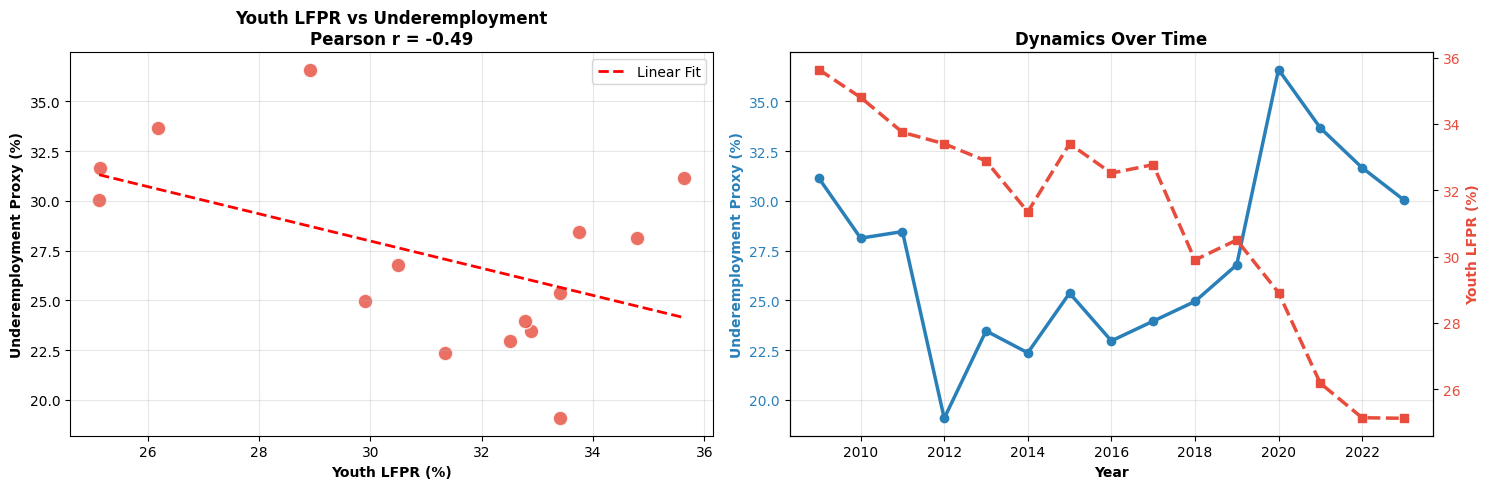

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Regression Scatter
ax1.scatter(youth_vals, underemp_vals, alpha=0.8, s=110, color='#e74c3c', edgecolors='white')
z = np.polyfit(youth_vals, underemp_vals, 1)
p = np.poly1d(z)
y_sorted = np.sort(youth_vals)
ax1.plot(y_sorted, p(y_sorted), "r--", linewidth=2, label='Linear Fit')
ax1.set_xlabel('Youth LFPR (%)', fontweight='bold')
ax1.set_ylabel('Underemployment Proxy (%)', fontweight='bold')
ax1.set_title(f'Youth LFPR vs Underemployment\nPearson r = {pearson_corr:.2f}', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Historical Dynamics (Dual Axis)
color_u = '#2980b9'
color_y = '#e74c3c'
ax2.plot(merged_df['Year'], underemp_vals, marker='o', linewidth=2.5, color=color_u)
ax2.set_xlabel('Year', fontweight='bold')
ax2.set_ylabel('Underemployment Proxy (%)', color=color_u, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_u)

ax2_twin = ax2.twinx()
ax2_twin.plot(merged_df['Year'], youth_vals, marker='s', linewidth=2.5, color=color_y, linestyle='--')
ax2_twin.set_ylabel('Youth LFPR (%)', color=color_y, fontweight='bold')
ax2_twin.tick_params(axis='y', labelcolor=color_y)
ax2.set_title('Dynamics Over Time', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()